# 2.5 ノンパラメトリック法 (Nonparametric Methods)

本ノートブックでは、ガウス分布やベータ分布のように特定の関数形を仮定するパラメトリック手法とは対照的に、データそのものから柔軟に分布の形状を推定する**ノンパラメトリック法 (Nonparametric Methods)** について学びます。
体積を固定する**カーネル密度推定法 (Kernel Density Estimators / Parzen window)** と、点数を固定する**K最近傍法 (K-Nearest Neighbours)** の理論的導出と実装・可視化を扱います。

## 2.5.0 ノンパラメトリック密度推定の基本原理

未知の確率密度 $p(\mathbf{x})$ から独立に生成された $N$ 個のデータ点 $\mathcal{D} = \{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ を考えます。
点 $\mathbf{x}$ を含む微小領域 $\mathcal{R}$ に1つのデータ点が入る確率 $P$ は、
$$ P = \int_\mathcal{R} p(\mathbf{x}) d\mathbf{x} $$
です。領域 $\mathcal{R}$ の体積を $V$ とし、領域内で $p(\mathbf{x})$ がほぼ一定と見なせるほど十分に小さいと仮定すると、
$$ P \simeq p(\mathbf{x}) V $$
となります。
一方、$N$ 個のデータ点のうち領域 $\mathcal{R}$ の内部に入る点の総数 $K$ は二項分布に従います。
$$ K \sim \mathrm{Bin}(K | N, P) $$
$N$ が十分大きいとき、二項分布の平均から $P \simeq \frac{K}{N}$ と推定できます。
これを上の近似と組み合わせることで、**ノンパラメトリック密度推定の基本方程式**が得られます。

$$ p(\mathbf{x}) \simeq \frac{K}{N V} $$

この式から、密度を推定するための2つの異なるアプローチが生まれます。
1. **カーネル法 (Kernel Estimator)**: 体積 $V$ を固定し、領域に含まれるデータ点数 $K$ を求める。
2. **最近傍法 (Nearest Neighbour Method)**: 点数 $K$ を固定し、ちょうど $K$ 個の点を含むように領域の体積 $V$ をデータ適応的に決定する。

## 2.5.1 カーネル密度推定法 (Kernel Density Estimators / Parzen Windows)

点 $\mathbf{x}$ を中心とする一辺の長さ $h$ の超立方体領域 $\mathcal{R}$ （体積 $V = h^D$）を考えます。
窓関数（カーネル関数）として、単位超立方体内の点に対して 1、それ以外で 0 を返す関数 $k(\mathbf{u})$ を定義すると、領域内のデータ点数は $K = \sum_{n=1}^N k\left(\frac{\mathbf{x} - \mathbf{x}_n}{h}\right)$ と表せます。

立方体窓関数は不連続なステップ関数であるため、得られる推定密度にも不自然な段差が生じます。
そこで、滑らかなカーネル関数（最も代表的なものは**ガウスカーネル**）を採用します。
$$ p(\mathbf{x}) = \frac{1}{N} \sum_{n=1}^N \frac{1}{(2\pi h^2)^{D/2}} \exp\left( -\frac{\|\mathbf{x} - \mathbf{x}_n\|^2}{2h^2} \right) $$

ここで、$h$ は**バンド幅 (Bandwidth)** または平滑化パラメータと呼ばれます。
- $h$ が小さすぎる場合: 各データ点に鋭いスパイクが立ち、過学習（分散大・バイアス小）
- $h$ が大きすぎる場合: 分布全体が過度に平滑化され、データの微細構造が消失（分散小・バイアス大）

Plot saved to: result/fig2_kde_bandwidth.png


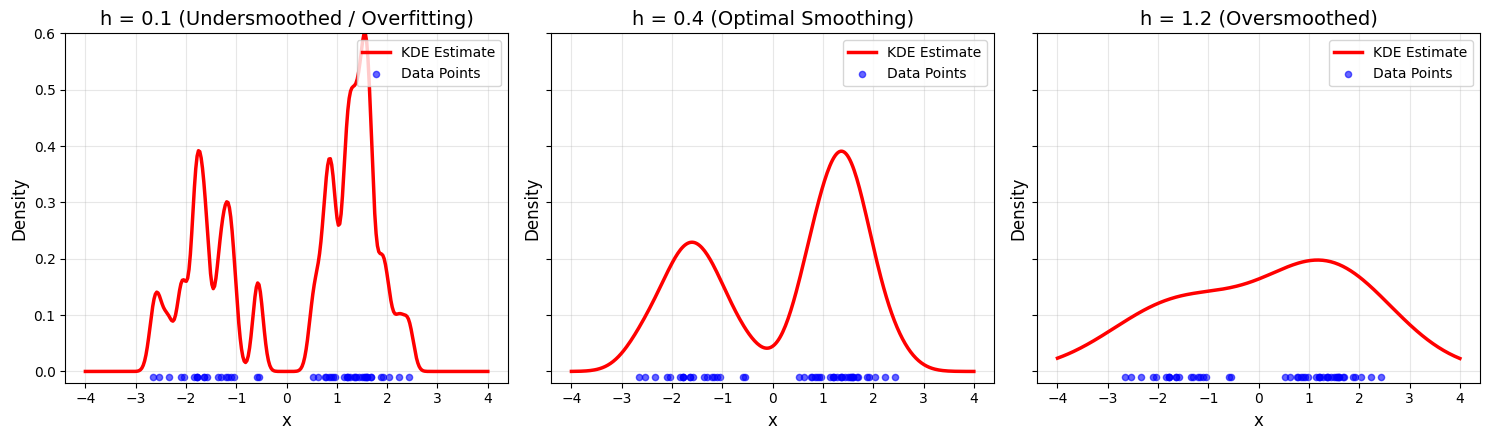

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
setup_style()

# PRML Figure 2.24 の再現: バンド幅 h によるカーネル密度推定の変化
np.random.seed(42)
# 混合ガウス分布から真のデータをサンプリング
N = 50
true_data = np.concatenate([np.random.normal(-1.5, 0.6, int(0.4*N)),
                            np.random.normal(1.5, 0.5, int(0.6*N))])

x_plot = np.linspace(-4, 4, 300)

def gaussian_kde_1d(x_eval, data, h):
    # p(x) = 1/N * sum( 1/(sqrt(2pi)*h) * exp(-(x - x_n)^2 / (2*h^2)) )
    diff = (x_eval[:, None] - data[None, :]) / h
    kernel_vals = np.exp(-0.5 * diff**2) / (np.sqrt(2 * np.pi) * h)
    return np.mean(kernel_vals, axis=1)

bandwidths = [0.1, 0.4, 1.2]
titles = ['h = 0.1 (Undersmoothed / Overfitting)',
          'h = 0.4 (Optimal Smoothing)',
          'h = 1.2 (Oversmoothed)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, h, title in zip(axes, bandwidths, titles):
    density = gaussian_kde_1d(x_plot, true_data, h)
    ax.plot(x_plot, density, 'r-', lw=2.5, label='KDE Estimate')
    # データ点のプロット
    ax.scatter(true_data, np.zeros_like(true_data) - 0.01, color='blue', s=20, alpha=0.6, clip_on=False, label='Data Points')
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.set_ylim(-0.02, 0.6)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

plt.tight_layout()
save_plot(fig, 'result', 'fig2_kde_bandwidth.png')
plt.show()

## 2.5.2 K最近傍法 (K-Nearest Neighbours)

カーネル法ではバンド幅 $h$（体積 $V$）を全空間で一律に固定するため、データが密集している領域では過剰に平滑化され、データが希薄な領域ではノイズの影響を受けやすくなります。
これに対し、**K最近傍法 (KNN)** では点数 $K$ を固定し、評価点 $\mathbf{x}$ を中心にちょうど $K$ 個の点を含む最小の球（半径 $r$、体積 $V$）をデータ適応的に決めます。

### KNN 分類器のベイズ的導出 (PRML 式 (2.254) - (2.256))
各クラス $\mathcal{C}_k$ のデータ数を $N_k$ （全データ数 $N = \sum_k N_k$）とします。
点 $\mathbf{x}$ を中心とする体積 $V$ の近傍球内に含まれる全 $K$ 個の点のうち、クラス $\mathcal{C}_k$ に属する点の個数を $K_k$ と置きます。

- クラス条件付き密度: $p(\mathbf{x} | \mathcal{C}_k) = \frac{K_k}{N_k V}$
- 全体密度: $p(\mathbf{x}) = \frac{K}{N V}$
- クラス事前確率: $p(\mathcal{C}_k) = \frac{N_k}{N}$

ベイズの定理を適用して事後確率 $p(\mathcal{C}_k | \mathbf{x})$ を計算すると、
$$ p(\mathcal{C}_k | \mathbf{x}) = \frac{p(\mathbf{x} | \mathcal{C}_k) p(\mathcal{C}_k)}{p(\mathbf{x})} = \frac{\frac{K_k}{N_k V} \cdot \frac{N_k}{N}}{\frac{K}{NV}} = \frac{K_k}{K} $$
体積 $V$ も各クラスのサンプル数 $N_k$ も驚くほど綺麗に相殺され、**点 $\mathbf{x}$ の近傍 $K$ 個に含まれるクラス $\mathcal{C}_k$ の割合そのものが事後確率になる**という極めて直感的かつ美しい結論が導かれます。

Plot saved to: result/fig2_knn_decision_boundary.png


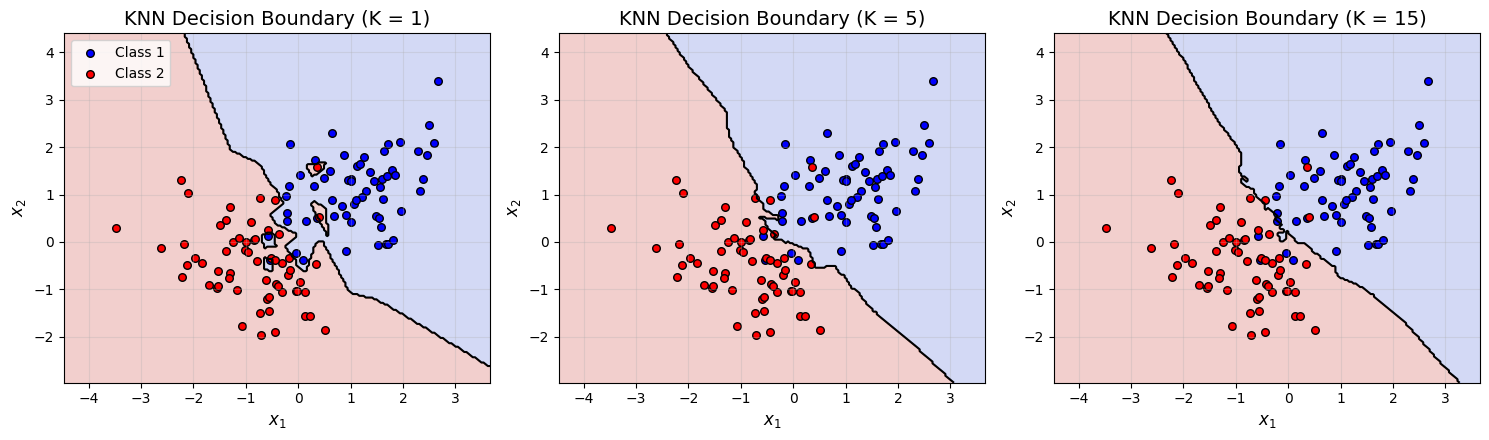

In [2]:
from sklearn.neighbors import KNeighborsClassifier

# PRML Figure 2.28 の再現: K の値による KNN 分類器の決定境界の変化
np.random.seed(42)
# 2クラスの合成データを生成
N_per_class = 60
mean1, cov1 = [1.0, 1.0], [[0.8, 0.4], [0.4, 0.8]]
mean2, cov2 = [-1.0, -0.5], [[0.7, -0.3], [-0.3, 0.7]]
X1 = np.random.multivariate_normal(mean1, cov1, N_per_class)
X2 = np.random.multivariate_normal(mean2, cov2, N_per_class)
X = np.vstack([X1, X2])
y = np.array([0]*N_per_class + [1]*N_per_class)

# グリッドの作成
x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

k_values = [1, 5, 15]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, k in zip(axes, k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)
    Z = knn.predict(grid_points).reshape(xx.shape)
    
    # 決定境界と領域のプロット
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.5)
    
    # データ点のプロット
    ax.scatter(X1[:, 0], X1[:, 1], color='blue', edgecolor='k', s=30, label='Class 1')
    ax.scatter(X2[:, 0], X2[:, 1], color='red', edgecolor='k', s=30, label='Class 2')
    
    ax.set_title(f'KNN Decision Boundary (K = {k})')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.grid(True, alpha=0.3)
    if k == 1:
        ax.legend(loc='upper left')

plt.tight_layout()
save_plot(fig, 'result', 'fig2_knn_decision_boundary.png')
plt.show()